In [ ]:
# repo root + config (walk parents; do not use ../..)
from pathlib import Path
import json
import yaml

def _repo_root() -> Path:
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "config" / "config.yaml").is_file():
            return p
    raise FileNotFoundError("config/config.yaml not found walking from " + str(start))

PROJECT_ROOT = _repo_root()
CFG_YAML = yaml.safe_load((PROJECT_ROOT / "config" / "config.yaml").read_text(encoding="utf-8"))
_cfg_json = PROJECT_ROOT / "config" / "config.json"
if _cfg_json.is_file():
    with open(_cfg_json, encoding="utf-8") as _f:
        CFG = json.load(_f)



# RQ2: Accuracy–stability dissociation

**Clean analysis notebook** (no re-inference). Quantifies where low semantic entropy
fails as a reliability signal.

| Dataset | Label | Entropy file | Entropy col | Accuracy col |
|---|---|---|---|---|
| CADEC | patient-generated health text | `outputs/rq3/entropy_cadec.csv` | `normalised_entropy` | `accuracy` |
| MedMentions | biomedical literature | `outputs/rq1/entropy_full_umls.csv` | `normalised_semantic_entropy_full` | `mean_accuracy_full` |

For each `(instance, model)`:

| | Correct | Wrong |
|---|---|---|
| **Stable** (\(\hat H = 0\)) | stable-correct | **stable-but-wrong** ← key cell |
| **Unstable** (\(\hat H > 0\)) | unstable-correct | unstable-wrong |

If entropy tracked correctness, stable-but-wrong ≈ 0. It will not.

Outputs: `outputs/<rq1|rq3>/rq2_dissociation_summary.csv` + stacked-bar figure per dataset.

In [1]:
# Setup
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = PROJECT_ROOT
assert (PROJECT_ROOT / "config" / "config.json").is_file()

DATASETS = {
    "MedMentions": {
        "label": "MedMentions (biomedical literature)",
        "entropy_path": PROJECT_ROOT / "outputs" / "rq1" / "entropy_full_umls.csv",
        "entropy_col": "normalised_entropy_dedup",
        "entropy_col_raw": "normalised_semantic_entropy_full",  # labelled sensitivity
        "retained_col": "retained_m_distinct",
        "accuracy_col": "mean_accuracy_full",
        "out_dir": PROJECT_ROOT / "outputs" / "rq1",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq1" / "figures",
    },
    "CADEC": {
        "label": "CADEC (patient-generated health text)",
        "entropy_path": PROJECT_ROOT / "outputs" / "rq3" / "entropy_cadec.csv",
        "entropy_col": "normalised_entropy_dedup",
        "entropy_col_raw": "normalised_entropy",  # labelled sensitivity
        "retained_col": "retained_m_distinct",
        "accuracy_col": "accuracy",
        "out_dir": PROJECT_ROOT / "outputs" / "rq3",
        "fig_dir": PROJECT_ROOT / "outputs" / "rq3" / "figures",
    },
}

for cfg in DATASETS.values():
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["fig_dir"].mkdir(parents=True, exist_ok=True)
    assert cfg["entropy_path"].is_file(), cfg["entropy_path"]
    print(f"OK {cfg['label']}: {cfg['entropy_path'].name}")

def _apply_retained_filter(df, cfg, ds_key):
    """Keep only rows retained under the PRIMARY de-duplicated denominator.

    docs/ANALYSIS_PRECOMMIT.md section 3 makes distinct-m primary. The producers emit every
    row that passes m_accepted >= 3 and record the de-duplicated inclusion decision in
    retained_m_distinct, so switching the denominator is a ROW FILTER as well as a column
    swap -- dropping it would read dedup entropy over the raw-m row set. For CADEC this
    moves the denominator from 5,161 instances to 5,022. Raw columns stay in place and are
    reachable via cfg["entropy_col_raw"] for the labelled sensitivity analysis.
    """
    col = cfg.get("retained_col")
    if not col or col not in df.columns:
        print(f"  WARNING {ds_key}: '{col}' absent from entropy file — NOT filtered; "
              f"rows are the raw-m set and the denominator is wrong")
        return df
    before, before_i = len(df), df["instance_id"].nunique()
    out = df[df[col].astype(bool)].copy()
    print(f"  {ds_key}: {col} filter | rows {before:,} -> {len(out):,} | "
          f"instances {before_i:,} -> {out['instance_id'].nunique():,}")
    return out


OK MedMentions (biomedical literature): entropy_full_umls.csv
OK CADEC (patient-generated health text): entropy_cadec.csv


## 1) Load + classify stable × correct (all 8 models)

In [2]:
# Load + 2x2 classification
def load_scored(ds_key: str) -> pd.DataFrame:
    cfg = DATASETS[ds_key]
    df = pd.read_csv(cfg["entropy_path"])
    df = _apply_retained_filter(df, cfg, ds_key)
    ecol, acol = cfg["entropy_col"], cfg["accuracy_col"]
    out = df[["instance_id", "model_name", ecol, acol]].copy()
    out = out.rename(columns={ecol: "entropy", acol: "accuracy"})
    out["entropy"] = pd.to_numeric(out["entropy"], errors="coerce")
    out["accuracy"] = pd.to_numeric(out["accuracy"], errors="coerce")
    out = out.dropna(subset=["entropy", "accuracy"]).copy()
    out["entropy"] = out["entropy"].clip(lower=0.0, upper=1.0)
    # Original-input correctness (0/1 in both files)
    out["correct"] = (out["accuracy"] >= 0.5).astype(int)
    out["stable"] = (out["entropy"] <= 1e-12).astype(int)
    out["cell"] = np.select(
        [
            (out["stable"] == 1) & (out["correct"] == 1),
            (out["stable"] == 1) & (out["correct"] == 0),
            (out["stable"] == 0) & (out["correct"] == 1),
            (out["stable"] == 0) & (out["correct"] == 0),
        ],
        ["stable_correct", "stable_but_wrong", "unstable_correct", "unstable_wrong"],
        default="other",
    )
    out["dataset"] = ds_key
    out["dataset_label"] = cfg["label"]
    return out


FRAMES = {k: load_scored(k) for k in DATASETS}
for k, df in FRAMES.items():
    print(
        f"{k}: n={len(df):,} models={df.model_name.nunique()} "
        f"instances={df.instance_id.nunique()} | "
        f"stable={(df.stable==1).mean():.3f} correct={(df.correct==1).mean():.3f} "
        f"SBW={(df.cell=='stable_but_wrong').mean():.3f}"
    )
    print(" ", sorted(df.model_name.unique()))


MedMentions: n=3,928 models=8 instances=491 | stable=0.501 correct=0.154 SBW=0.412
  ['BERT-base', 'BioBERT', 'BioMistral-7B', 'FLAN-T5-base', 'Llama3-OpenBioLLM-8B', 'Meta-Llama-3-8B-Instruct', 'Mistral-7B-Instruct-v0.1', 'PubMedBERT']
CADEC: n=44,848 models=8 instances=5669 | stable=0.625 correct=0.341 SBW=0.328
  ['BERT-base', 'BioBERT', 'BioMistral-7B', 'FLAN-T5-base', 'Llama3-OpenBioLLM-8B', 'Meta-Llama-3-8B-Instruct', 'Mistral-7B-Instruct-v0.1', 'PubMedBERT']


## 2) Per-model 2×2 + correlations + summary CSV

In [3]:
# Per-model dissociation summary
CELL_ORDER = ["stable_correct", "stable_but_wrong", "unstable_correct", "unstable_wrong"]


def summarise(ds_key: str, df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model, g in df.groupby("model_name"):
        n = len(g)
        counts = g["cell"].value_counts()
        fracs = {c: float(counts.get(c, 0) / n) for c in CELL_ORDER}
        n_counts = {c: int(counts.get(c, 0)) for c in CELL_ORDER}
        # corr(entropy, 1-accuracy): positive => higher entropy co-occurs with errors
        err = 1.0 - g["accuracy"].astype(float)
        if g["entropy"].nunique() > 1 and err.nunique() > 1:
            pear = float(stats.pearsonr(g["entropy"], err).statistic)
            spear = float(stats.spearmanr(g["entropy"], err).statistic)
        else:
            pear, spear = float("nan"), float("nan")
        rows.append({
            "dataset": ds_key,
            "dataset_label": DATASETS[ds_key]["label"],
            "model_name": model,
            "n": n,
            "frac_stable": float(g["stable"].mean()),
            "frac_correct": float(g["correct"].mean()),
            "n_stable_correct": n_counts["stable_correct"],
            "n_stable_but_wrong": n_counts["stable_but_wrong"],
            "n_unstable_correct": n_counts["unstable_correct"],
            "n_unstable_wrong": n_counts["unstable_wrong"],
            "frac_stable_correct": fracs["stable_correct"],
            "frac_stable_but_wrong": fracs["stable_but_wrong"],
            "frac_unstable_correct": fracs["unstable_correct"],
            "frac_unstable_wrong": fracs["unstable_wrong"],
            # Among stable rows, P(wrong): purity of stability as correctness signal
            "p_wrong_given_stable": (
                float(1.0 - g.loc[g["stable"] == 1, "correct"].mean())
                if (g["stable"] == 1).any() else float("nan")
            ),
            "pearson_entropy_vs_error": pear,
            "spearman_entropy_vs_error": spear,
        })
    return pd.DataFrame(rows).sort_values("frac_stable_but_wrong", ascending=False)


SUMMARIES = {}
for ds_key, df in FRAMES.items():
    sm = summarise(ds_key, df)
    SUMMARIES[ds_key] = sm
    out_csv = DATASETS[ds_key]["out_dir"] / "rq2_dissociation_summary.csv"
    sm.to_csv(out_csv, index=False)
    print(f"\n===== {DATASETS[ds_key]['label']} =====")
    print(f"Wrote {out_csv}")
    show = sm[[
        "model_name", "frac_stable", "frac_correct", "frac_stable_but_wrong",
        "p_wrong_given_stable", "pearson_entropy_vs_error", "spearman_entropy_vs_error",
    ]].copy()
    print(show.to_string(index=False, float_format=lambda x: f"{x:.3f}"))



===== MedMentions (biomedical literature) =====
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/rq2_dissociation_summary.csv
              model_name  frac_stable  frac_correct  frac_stable_but_wrong  p_wrong_given_stable  pearson_entropy_vs_error  spearman_entropy_vs_error
              PubMedBERT        0.611         0.033                  0.589                 0.963                     0.035                      0.032
               BERT-base        0.593         0.039                  0.566                 0.955                     0.051                      0.050
                 BioBERT        0.582         0.071                  0.525                 0.902                     0.127                      0.133
           BioMistral-7B        0.507         0.218                  0.389                 0.767                     0.050                      0.043
Meta-Llama-3-8B-Instruct        0.473         0.220                  0.350        


===== CADEC (patient-generated health text) =====
Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/rq2_dissociation_summary.csv
              model_name  frac_stable  frac_correct  frac_stable_but_wrong  p_wrong_given_stable  pearson_entropy_vs_error  spearman_entropy_vs_error
    Llama3-OpenBioLLM-8B        0.978         0.422                  0.557                 0.570                     0.106                      0.110
            FLAN-T5-base        0.507         0.205                  0.375                 0.740                     0.138                      0.138
Meta-Llama-3-8B-Instruct        0.705         0.366                  0.349                 0.495                     0.422                      0.442
Mistral-7B-Instruct-v0.1        0.619         0.357                  0.339                 0.547                     0.269                      0.269
           BioMistral-7B        0.456         0.244                  0.313      

## 3) Figures: stacked composition + stable-but-wrong highlight

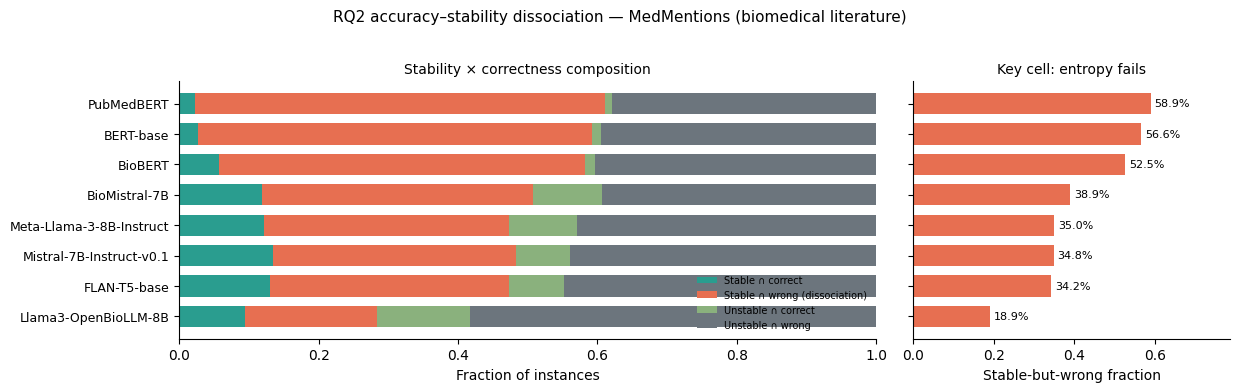

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq1/figures/rq2_dissociation_stable_but_wrong.png


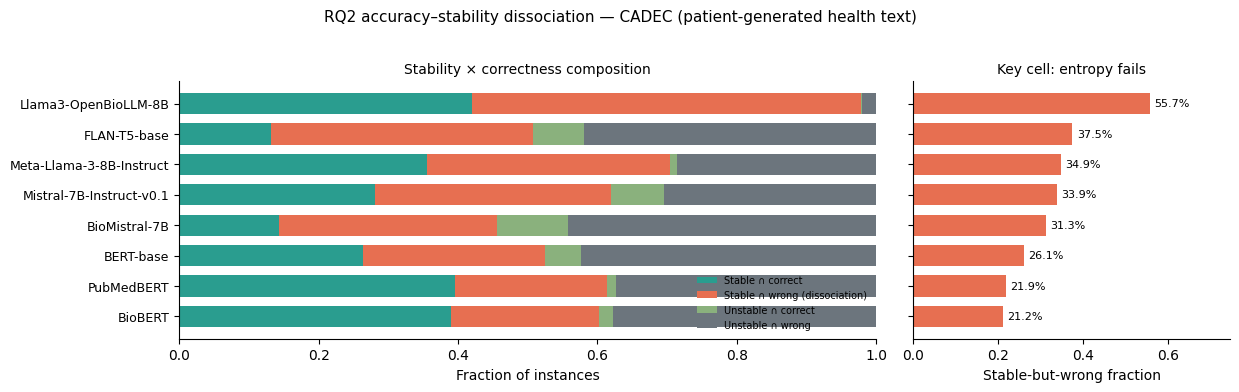

Wrote /home/s224858267/projects/Measuring-Semantic-Stability-in-Clinical-LLMs/outputs/rq3/figures/rq2_dissociation_stable_but_wrong.png


In [4]:
# Figures
COLORS = {
    "stable_correct": "#2a9d8f",
    "stable_but_wrong": "#e76f51",  # highlight dissociation
    "unstable_correct": "#8ab17d",
    "unstable_wrong": "#6c757d",
}
LABELS = {
    "stable_correct": "Stable ∩ correct",
    "stable_but_wrong": "Stable ∩ wrong (dissociation)",
    "unstable_correct": "Unstable ∩ correct",
    "unstable_wrong": "Unstable ∩ wrong",
}


def plot_dataset(ds_key: str, sm: pd.DataFrame):
    cfg = DATASETS[ds_key]
    sm = sm.sort_values("frac_stable_but_wrong", ascending=True)
    models = sm["model_name"].tolist()
    y = np.arange(len(models))
    fig, axes = plt.subplots(1, 2, figsize=(12.5, max(3.8, 0.45 * len(models))),
                             gridspec_kw={"width_ratios": [2.2, 1.0]})

    # Left: stacked horizontal bars (2x2 composition)
    ax = axes[0]
    left = np.zeros(len(models))
    for cell in CELL_ORDER:
        vals = sm[f"frac_{cell}"].to_numpy()
        ax.barh(y, vals, left=left, color=COLORS[cell], label=LABELS[cell], height=0.7)
        left = left + vals
    ax.set_yticks(y)
    ax.set_yticklabels(models, fontsize=9)
    ax.set_xlabel("Fraction of instances")
    ax.set_xlim(0, 1)
    ax.set_title("Stability × correctness composition", fontsize=10)
    ax.legend(loc="lower right", fontsize=7, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Right: SBW fraction bars
    ax = axes[1]
    sbw = sm["frac_stable_but_wrong"].to_numpy()
    ax.barh(y, sbw, color="#e76f51", height=0.7)
    for yi, v in zip(y, sbw):
        ax.text(v + 0.01, yi, f"{v:.1%}", va="center", fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels([])
    ax.set_xlabel("Stable-but-wrong fraction")
    ax.set_xlim(0, min(1.0, sbw.max() * 1.25 + 0.05))
    ax.set_title("Key cell: entropy fails", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.suptitle(
        f"RQ2 accuracy–stability dissociation — {cfg['label']}",
        fontsize=11,
        y=1.02,
    )
    fig.tight_layout()
    fig_path = cfg["fig_dir"] / "rq2_dissociation_stable_but_wrong.png"
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Wrote {fig_path}")


for ds_key, sm in SUMMARIES.items():
    plot_dataset(ds_key, sm)


## 4) Dissociation highlights

In [5]:
# Narrative highlights
print("=" * 78)
print("RQ2 DISSOCIATION HIGHLIGHTS")
print("CADEC = patient-generated health text (not clinical notes)")
print("=" * 78)

for ds_key, sm in SUMMARIES.items():
    cfg = DATASETS[ds_key]
    print(f"\n### {cfg['label']}")
    worst = sm.iloc[0]  # sorted by SBW desc
    best = sm.sort_values("frac_stable_but_wrong", ascending=True).iloc[0]
    # highest stability with low accuracy (dissociation signature)
    sm2 = sm.copy()
    sm2["dissoc_score"] = sm2["frac_stable"] * (1.0 - sm2["frac_correct"])
    extreme = sm2.sort_values("dissoc_score", ascending=False).iloc[0]

    print(
        f"  Highest stable-but-wrong: {worst['model_name']}\n"
        f"    SBW={worst['frac_stable_but_wrong']:.1%} | stable={worst['frac_stable']:.1%} | "
        f"correct={worst['frac_correct']:.1%} | P(wrong|stable)={worst['p_wrong_given_stable']:.1%}\n"
        f"    corr(H, error): pearson={worst['pearson_entropy_vs_error']:+.3f} "
        f"spearman={worst['spearman_entropy_vs_error']:+.3f}"
    )
    print(
        f"  Lowest stable-but-wrong: {best['model_name']}\n"
        f"    SBW={best['frac_stable_but_wrong']:.1%} | stable={best['frac_stable']:.1%} | "
        f"correct={best['frac_correct']:.1%} | "
        f"corr spearman={best['spearman_entropy_vs_error']:+.3f}"
    )
    print(
        f"  Strongest stability–accuracy dissociation score "
        f"(stable × (1−acc)): {extreme['model_name']}\n"
        f"    stable={extreme['frac_stable']:.1%} correct={extreme['frac_correct']:.1%} "
        f"SBW={extreme['frac_stable_but_wrong']:.1%}"
    )

# Explicit OpenBioLLM-CADEC callout
cad = SUMMARIES["CADEC"].set_index("model_name")
if "Llama3-OpenBioLLM-8B" in cad.index:
    r = cad.loc["Llama3-OpenBioLLM-8B"]
    print("\n### Extreme case: OpenBioLLM on CADEC (patient-generated health text)")
    print(
        f"  Near-ceiling stability ({r['frac_stable']:.1%}) with modest accuracy "
        f"({r['frac_correct']:.1%}) → stable-but-wrong = {r['frac_stable_but_wrong']:.1%}.\n"
        f"  P(wrong | stable) = {r['p_wrong_given_stable']:.1%}. "
        f"Entropy collapses to zero while predictions remain often incorrect — "
        f"stability is not a reliability signal here."
    )
    # Contrast with best tracker on CADEC (highest spearman of H vs error among reasonable SBW)
    track = SUMMARIES["CADEC"].dropna(subset=["spearman_entropy_vs_error"]).sort_values(
        "spearman_entropy_vs_error", ascending=False
    ).iloc[0]
    print(
        f"  Contrast (best H↔error Spearman on CADEC): {track['model_name']} "
        f"spearman={track['spearman_entropy_vs_error']:+.3f} "
        f"SBW={track['frac_stable_but_wrong']:.1%} "
        f"stable={track['frac_stable']:.1%} correct={track['frac_correct']:.1%}"
    )

print("\n" + "=" * 78)
for ds_key, cfg in DATASETS.items():
    print(f"Summary: {cfg['out_dir'] / 'rq2_dissociation_summary.csv'}")
    print(f"Figure:  {cfg['fig_dir'] / 'rq2_dissociation_stable_but_wrong.png'}")


RQ2 DISSOCIATION HIGHLIGHTS
CADEC = patient-generated health text (not clinical notes)

### MedMentions (biomedical literature)
  Highest stable-but-wrong: PubMedBERT
    SBW=58.9% | stable=61.1% | correct=3.3% | P(wrong|stable)=96.3%
    corr(H, error): pearson=+0.035 spearman=+0.032
  Lowest stable-but-wrong: Llama3-OpenBioLLM-8B
    SBW=18.9% | stable=28.3% | correct=22.8% | corr spearman=+0.244
  Strongest stability–accuracy dissociation score (stable × (1−acc)): PubMedBERT
    stable=61.1% correct=3.3% SBW=58.9%

### CADEC (patient-generated health text)
  Highest stable-but-wrong: Llama3-OpenBioLLM-8B
    SBW=55.7% | stable=97.8% | correct=42.2% | P(wrong|stable)=57.0%
    corr(H, error): pearson=+0.106 spearman=+0.110
  Lowest stable-but-wrong: BioBERT
    SBW=21.2% | stable=60.3% | correct=41.0% | corr spearman=+0.586
  Strongest stability–accuracy dissociation score (stable × (1−acc)): Llama3-OpenBioLLM-8B
    stable=97.8% correct=42.2% SBW=55.7%

### Extreme case: OpenBioLLM 